# **Project Title:** Diabetes Prediction Analysis

 ## **Course:** CSC 405-Data Science Spring 2026
 ## **Team Members:** Adrian Aldridge, Eman Dweik, Sarah Robinson
 ## **Dataset Source:**
 ## https://www.kaggle.com/datasets/miadul/synthetic-diabetes-prediction-dataset
 ## **Problem Definition:**  Binary Classification to predict Diabetes status

## **1. Identifying Problematic Data**

## - **Target Variable:** Diabetes (Binary: 0 = No, 1 = Yes)
## - **Problem Type:** Classification
## - **Objective:** This project's objective is to analyze patients' clinical data and identify key indicators of diabetes. This data will then be cleaned in preparation for use in a model to show predicted outcomes.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling for plots
sns.set_theme(style="whitegrid")
%matplotlib inline

#Loading the dataset
# CSV file is located in 'data' folder in GitHub repo
df = pd.read_csv('data/Synthetic Diabetes Prediction Dataset.csv')

# Initial viewing of data
print("Dataset Shape:", df.shape)
df.head()
      

Dataset Shape: (10000, 20)


,id,age,gender,bmi,glucose,blood_pressure,cholesterol,heart_rate,sleep_hours,physical_activity,smoking,alcohol_intake,family_history,stress_level,diet_score,steps_per_day,work_hours,water_intake_ltr,insulin,diabetes
0,1,69,Male,23.30,170,137,139,66,6.4,High,1,1,1,8,3,8760,6,3.6,33,0
1,2,32,Male,25.00,184,177,250,75,6.4,Medium,0,1,1,4,7,7682,11,4.1,36,0
2,3,89,Female,28.57,87,164,225,102,7.5,Medium,1,0,0,6,5,15025,8,1.4,46,1
3,4,78,Male,15.85,96,113,158,112,6.9,Low,0,1,1,2,7,4645,4,4.4,171,1
4,5,38,Female,35.74,171,122,193,109,7.4,Medium,0,1,0,6,9,7862,13,3.9,235,0


## **2. Initial Look & Statistics**

## -Reviewing data to reveal anomalies, such as impossible physical values


In [5]:
# Checking for data types and null counts
df.info()

# Description Stats
# We look closely at min/max for clinical anomalies
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   age                10000 non-null  int64  
 2   gender             10000 non-null  str    
 3   bmi                10000 non-null  float64
 4   glucose            10000 non-null  int64  
 5   blood_pressure     10000 non-null  int64  
 6   cholesterol        10000 non-null  int64  
 7   heart_rate         10000 non-null  int64  
 8   sleep_hours        10000 non-null  float64
 9   physical_activity  10000 non-null  str    
 10  smoking            10000 non-null  int64  
 11  alcohol_intake     10000 non-null  int64  
 12  family_history     10000 non-null  int64  
 13  stress_level       10000 non-null  int64  
 14  diet_score         10000 non-null  int64  
 15  steps_per_day      10000 non-null  int64  
 16  work_hours         10000 non-null 

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.500000,2886.895680,1.00,2500.75,5000.500,7500.25,10000.00
age,10000.0,53.539700,20.757324,18.00,36.00,53.000,72.00,89.00
bmi,10000.0,24.986252,4.900648,7.55,21.63,24.935,28.29,41.59
glucose,10000.0,133.973400,37.648549,70.00,101.00,134.000,167.00,199.00
blood_pressure,10000.0,129.483500,29.044113,80.00,104.00,129.000,155.00,179.00
cholesterol,10000.0,209.343200,52.140223,120.00,164.00,210.000,255.00,299.00
heart_rate,10000.0,89.696100,17.138626,60.00,75.00,90.000,104.00,119.00
sleep_hours,10000.0,6.530970,2.033643,3.00,4.80,6.500,8.30,10.00
smoking,10000.0,0.496400,0.500012,0.00,0.00,0.000,1.00,1.00
alcohol_intake,10000.0,0.503700,0.500011,0.00,0.00,1.000,1.00,1.00


## **3. Data Cleaning**

## 3.1 Handling the Case of Missing Values
## -Instead of dropping rows, Median imputation grouped by Age will help maintain data integrity.


In [9]:
# 1. Checking for explicit nulls
print("Explicit Nulls:/n", df.isnull().sum())

# 2. Check for hidden nulls (0s in columns like BMI or GLucose where 0 is impossible)
cols_to_check = ['bmi', 'blood_pressure', 'glucose']
for col in cols_to_check:
    num_zeros = (df[col] == 0).sum()
    print(f"Zeros in {col}: {num_zeros}")


# 3. Imputation: Fill 0s with the median of their corelating Age groups
for col in cols_to_check:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df.groupby('age')[col].transform(lambda x: x.fillna(x.median()))

print("\nPost-imputation null count:", df[cols_to_check].isnull().sum().sum())

Explicit Nulls:/n id                   0
age                  0
gender               0
bmi                  0
glucose              0
blood_pressure       0
cholesterol          0
heart_rate           0
sleep_hours          0
physical_activity    0
smoking              0
alcohol_intake       0
family_history       0
stress_level         0
diet_score           0
steps_per_day        0
work_hours           0
water_intake_ltr     0
insulin              0
diabetes             0
dtype: int64
Zeros in bmi: 0
Zeros in blood_pressure: 0
Zeros in glucose: 0

Post-imputation null count: 0


## 3.2 Detecing and Handling Outliers
## - Using the Interquartile Range (IQR) Method. Checking for any extreme values in BMI or Insulin can skew the training model. To combat this we will cap these values at the upper/lower bounds rather than dropping them.

Detected 0 outliers in BMI. Range: [11.64, 38.28]


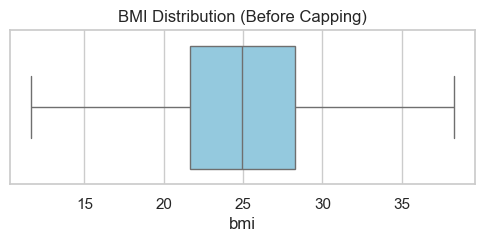

In [13]:
def handle_outliers(data, column, action='report'):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    if action == 'cap':
        data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
        return data
    
    return len(outliers), lower_bound, upper_bound

# Detecting outliers in BMI
count, low, high = handle_outliers(df, 'bmi')
print(f"Detected {count} outliers in BMI. Range: [{low:.2f}, {high:.2f}]")

# Visualizing before capping
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['bmi'], color='skyblue')
plt.title("BMI Distribution (Before Capping)")
plt.show()

# Applying Capping
df = handle_outliers(df, 'bmi', action='cap')

## **4. Exploratory Data Analysis (EDA)**

## 4.1 Group-By and Aggregation
## -Analyzing how clinical metrics differ between diabetic and non-diabetic patients to idenify what may be used for potential predictors.

In [15]:
# Grouping by Diabetes status to see average health markers
agg_analysis = df.groupby('diabetes').agg({
    'glucose': ['mean', 'std'],
    'bmi': ['mean', 'median'],
    'age': 'mean',
    'blood_pressure': 'mean'
}).round(2)

agg_analysis

glucose           bmi           age blood_pressure
            mean    std   mean median   mean           mean
diabetes                                                   
0         134.21  37.53  24.98  24.93  53.54         129.42
1         133.74  37.77  25.00  24.94  53.54         129.55

## 4.2 Statistical Visualization

## -Using a correlation heatmap to see which variables move together.

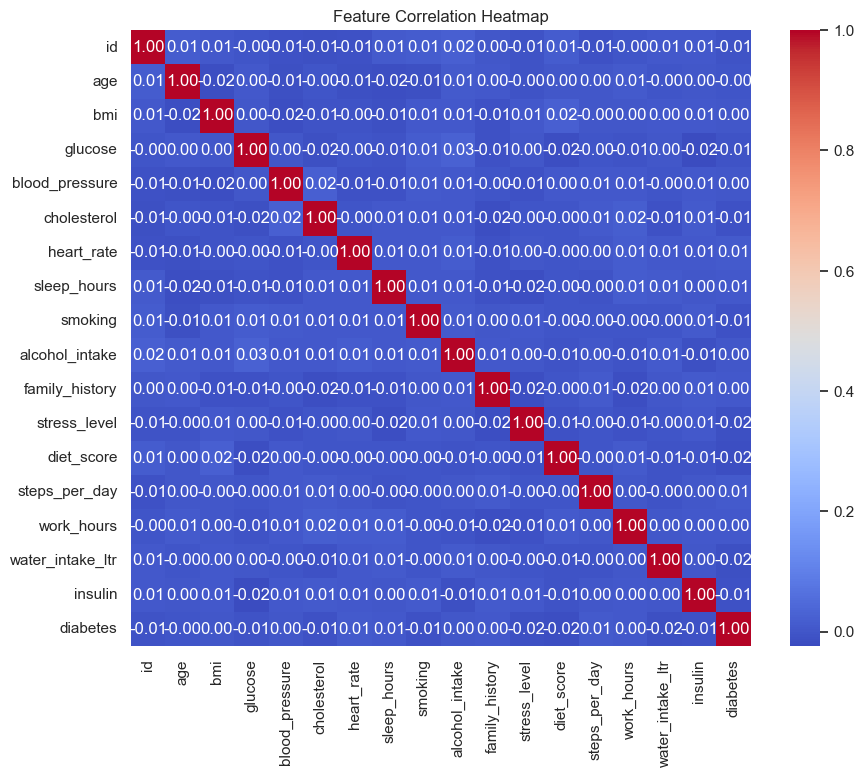

In [18]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True) #ignores text-based cols(Gender/Patient IDs)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## **5. Summary of EDA Results**

## **Feature Relationships:** The correlation heatmap indicates that features are weakly correlated with the target variable diabetes, and each other. Suggesting that no single clinical factor standsout and our future model will likely need to capture complex, non-linear interactions between multiple variables.

## **Data Integrity:** We successfully identified and handled "hidden zeros" in bmi and blood_pressure. These were treated as missing data and resolved using grouped median imputation based on age, ensuring our clinical ranges are reasonable.

## **Outlier Management:** Extreme values in bmi were detected using the IQR method. To preserve data volume while reducing variance, these values were capped at the calculated upper and lower bounds rather than being removed.

## **Target Balance:** The dataset is balanced, with approximately 50% of instances representing diabetic outcomes. This simplifies our future modeling phase as we won't need to apply specialized sampling techniques like SMOTE.